In [14]:
from astropy.io import fits
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pickle

from scipy.optimize import curve_fit
import scipy.stats as ss
from sklearn.decomposition import PCA

import re  # find pattern in string
from tqdm import tqdm  # progress bar
import logging  # to avoid printing too many warnings

import tools as t

In [15]:
# define the path of the directory where dace data is saved
path_data = '../tests/HD110315-master/data/s1d/HARPN/'
direc = 'STACKED/'  # sub directory where the specific data is
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [16]:
# iterate over saved files in direc
# save names of the files
files = []
for entry in os.scandir(path_dace + direc):
    name = entry.name
    if name.endswith('.p'):
        files.append(entry.name)

print(files)

['RASSINE_Stacked_spectrum_B1.00_D2014-01-07T05:46:43.123.p', 'Stacked_spectrum_B1.00_D2015-04-04T01:59:26.396.p', 'Stacked_spectrum_B1.00_D2014-05-24T23:35:58.502.p', 'Stacked_spectrum_B1.00_D2014-05-20T23:19:09.696.p', 'Stacked_spectrum_B1.00_D2013-01-18T05:05:51.512.p', 'Stacked_spectrum_B1.00_D2014-04-22T02:07:45.494.p', 'RASSINE_Stacked_spectrum_B1.00_D2014-03-07T04:18:36.073.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-01-31T04:44:05.628.p', 'RASSINE_Stacked_spectrum_B1.00_D2018-04-30T23:47:02.054.p', 'Stacked_spectrum_B1.00_D2013-01-14T06:09:18.317.p', 'RASSINE_Stacked_spectrum_B1.00_D2014-04-22T02:07:45.494.p', 'Stacked_spectrum_B1.00_D2014-03-07T04:18:36.073.p', 'RASSINE_Stacked_spectrum_B1.00_D2014-05-20T23:19:09.696.p', 'RASSINE_Stacked_spectrum_B1.00_D2013-01-18T05:05:51.512.p', 'RASSINE_Stacked_spectrum_B1.00_D2013-01-14T06:09:18.317.p', 'Stacked_spectrum_B1.00_D2015-01-31T04:44:05.628.p', 'Stacked_spectrum_B1.00_D2018-04-30T23:47:02.054.p', 'Stacked_spectrum_B1.00_D2014-01-0

In [58]:
path_file = path_data + direc + files[0]
data = pickle.load(open(path_file, "rb"))
print(type(data))
print(data.keys())
wl = data['wave']
flux = data['flux'] / data['output']['continuum_linear']

<class 'dict'>
dict_keys(['wave', 'flux', 'flux_err', 'flux_used', 'output', 'parameters', 'matching_anchors', 'matching_diff'])


In [59]:
path_file

'../tests/HD110315-master/data/s1d/HARPN/STACKED/RASSINE_Stacked_spectrum_B1.00_D2014-01-07T05:46:43.123.p'

In [60]:
len(data['output']['continuum_linear'])

303425

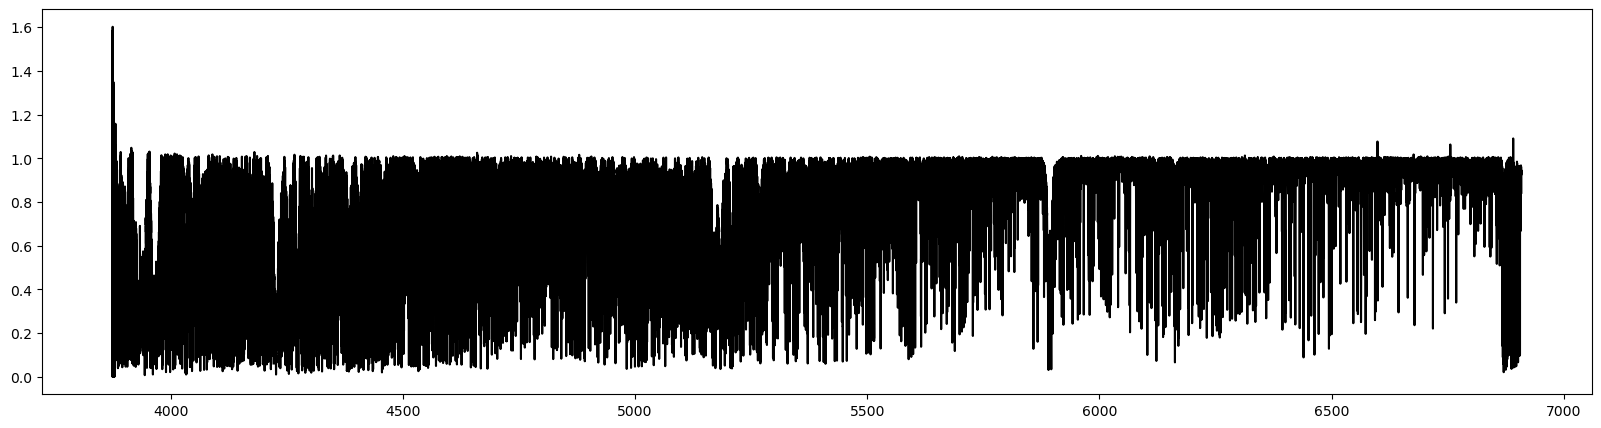

In [63]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(wl, flux, 'k')
plt.show()

In [32]:
data = pd.read_csv(path_data + 'stacked_basic.csv')
data.columns

Index(['name', 'group', 'instrument', 'mjd', 'rv_mean', 'rv_shift', 'SNR_5500',
       'jdb', 'berv', 'berv_min', 'berv_max', 'lamp_offset', 'acc_sec',
       'hole_left', 'hole_right', 'wave_min', 'wave_max', 'dwave',
       'stacking_length', 'nb_spectra_stacked', 'nb_bins', 'mean_jdb',
       'mean_vrad', 'mean_svrad'],
      dtype='object')

In [ ]:
# iterate over saved files in direc
# save names (observation dates) of the files
dates_files = []
for entry in os.scandir(path_dace + direc):
    if entry.name != 'spectra.txt' and entry.name != 'CCF':
        dates_files.append(entry.name)

dates_files = sorted(dates_files, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))  # sort
print(dates_files)

['2018-06-01', '2018-06-02', '2018-06-03', '2018-06-04', '2018-06-05', '2018-06-06', '2018-06-07', '2018-06-08', '2018-06-09', '2018-06-10', '2018-06-11', '2018-06-12', '2018-06-13', '2018-06-14', '2018-06-15', '2018-06-16', '2018-06-17', '2018-06-18', '2018-06-19', '2018-06-20', '2018-06-21', '2018-06-22', '2018-06-23', '2018-06-24', '2018-06-25', '2018-06-26', '2018-06-27', '2018-06-28', '2018-06-29', '2018-06-30']


In [ ]:
# make a list of the available files that end by A.fits (s1d)
files_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_list.extend(files)  # save file names
files_list = [s for s in files_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_list = np.array(files_list)
print(f's1d files: {len(files_list)}')

# make a list of the available files that end by A.fits (CCF)
files_ccf_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + 'CCF/' + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_ccf_list.extend(files)  # save file names
#files_ccf_list = [s for s in files_ccf_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_ccf_list = np.array(files_ccf_list)
print(f'ccf files: {len(files_ccf_list)}')

s1d files: 703
ccf files: 703


In [6]:
# keep only ccf files that have a corresponding s1d file
files_s1d = []
files_ccf = []

for i in files_ccf_list:
    s1d_file = i.replace('CCF', 'S1D')
    if s1d_file in files_list:
        files_s1d.append(s1d_file)
        files_ccf.append(i)

files_s1d = np.array(files_s1d)
files_ccf = np.array(files_ccf)
print(len(files_ccf), len(files_s1d))

602 602


In [9]:
path_file = path_dace + direc + files_s1d[0]
hdul = fits.open(path_file)  # open file

wave = hdul[1].data["wavelength"]
flux = hdul[1].data["flux"]
err  = hdul[1].data["error"]